# Making Roman Mosaics

## Introduction

This notebook demonstrates the use of ROSALIA to make mosaics in MAST on commissioning data products.

## Imports

In [1]:
import rosalia as rs
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.coordinates import SkyCoord  # High-level coordinates

ROSALIA assumes you have a valid MAST AUTH token to access the requested data.  

If you do not have a MAST AUTH token for accessing MAST (needed for Roman OPS access until after commissioning), or if your token has expired, make one now by visiting [MAST.Auth](https://auth.mast.stsci.edu/info).

Once you have a token, you can set it up as an environment variable for later use, or you can store it in a file called `variables.env`. Below, we have assumed the file is in your current working directory (`./`), but the full path to the file can be specified if it is stored elsewhere such as your home directory. The `variables.env` file should look like:

```
MAST_API_TOKEN='yourtokenhere'
```

Here we assume you stored it as an environment variable (recommended). The line to add to your .bashrc/.zshrc would look like:

```
export MAST_API_TOKEN='yourtokenhere'
```

In [2]:
import os
from astroquery.mast import MastMissions
from dotenv import load_dotenv

_ = load_dotenv(dotenv_path="./variables.env")

# Create MastMissions object and assign mission to 'roman'
missions = MastMissions(mission='roman')

# Login to search and retrieve Roman data
token = os.getenv("MAST_API_TOKEN")    
missions.login(token=token)
               
print(f'Mission: {missions.mission}')
print(f'Service: {missions.service}')

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Mission: roman
Service: search


In [32]:
"""
Example of criteria for a roman_query using astroquery.mast.query_criteria
search = {'program': 1020,
         'observation': 5,
         'pass': 2, 
         #'exposure_start_time': '2026-09-15T02:01:47.4080000',
         'product_type': 'l2', 
         'detector': 'WFI06',
         # 'optical_element': 'F158',
         'exposure_type': "WFI_IMAGE"}

Here we use a region criteria, based on a set of coordinates and a search radius.


    program_id = visit_id[0:5]
    plan_id = visit_id[5:7]
    pass_id = visit_id[7:10]
    segment_id = visit_id[10:13]

    'exposure_id': '0102203058001001001',
01022 03 058 001 001 001
"""

#coordinates=SkyCoord(229.64044*u.deg, -3.58747*u.deg, frame="icrs")
#radius=10*u.arcsec

# query = roman_query_criteria(search=search, file_suffix="_cal")
# results, products = rs.mast.roman_query(coordinates=coordinates, radius=radius, file_suffix="_cal")


search = {'program': 1022,
          'execution_plan': 3,
          'pass': 53,
          'segment': 1,
          # 'observation': 2,
          # 'visit': 1,
          'product_type': 'l2', 
          'exposure_type': "WFI_IMAGE",
          }

results, products, exposures = rs.mast.roman_query(search, file_suffix="_cal")



INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Mission: roman
Service: search
INFO: 70 of 468 products were duplicates. Only returning 398 unique product(s). [astroquery.mast.utils]
INFO: To return all products, use `MastMissions.get_product_list` [astroquery.mast.missions]


In [33]:
results

fileSetName,productLevel,optical_element,exposure_time,program,pass,segment,exposure_type,detector,ArchiveFileID,product_type,execution_plan,observation,instrument_name,visit,exposure_start_time,exposure_end_time
str36,str7,str4,float64,int64,str2,str1,str9,str5,str7,str2,int64,int64,str3,int64,str27,str27
r0102203053001002001_0001_wfi01_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI01,2206748,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi02_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI02,2207466,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi03_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI03,2208003,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi04_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI04,2207342,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi05_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI05,2206567,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi06_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI06,2207548,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi07_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI07,2206923,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi08_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI08,2208730,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000
r0102203053001002001_0001_wfi09_f087,"1, 2, 4",F087,151.79858,1022,53,1,WFI_IMAGE,WFI09,2208440,l2,3,2,WFI,1,2026-09-21T04:24:30.5960000,2026-09-21T04:27:05.5570000


In [34]:
roman_exposure = rs.core.exposure(products)

  0%|          | 0/18 [00:00<?, ?it/s]

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Filter F087 found in cache. Loading from /Users/aborlaff/NASA/rosalia_cache//CORE/filters/ROMAN_WFI_WFI_F087.pkl


  6%|▌         | 1/18 [00:28<07:57, 28.07s/it]

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Filter F087 found in cache. Loading from /Users/aborlaff/NASA/rosalia_cache//CORE/filters/ROMAN_WFI_WFI_F087.pkl


 11%|█         | 2/18 [00:47<06:07, 22.95s/it]

...

 89%|████████▉ | 16/18 [07:32<01:00, 30.05s/it]

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Filter F087 found in cache. Loading from /Users/aborlaff/NASA/rosalia_cache//CORE/filters/ROMAN_WFI_WFI_F087.pkl


 94%|█████████▍| 17/18 [08:01<00:29, 29.84s/it]

INFO: MAST API token accepted, welcome Alejandro Serrano Borlaff [astroquery.mast.auth]
Filter F087 found in cache. Loading from /Users/aborlaff/NASA/rosalia_cache//CORE/filters/ROMAN_WFI_WFI_F087.pkl


100%|██████████| 18/18 [08:30<00:00, 28.37s/it]


2026-09-22T16:08:00.183577 > Fetching catalog
INFO: radius parameter (minimum distance to search for individual stars) is > 0.5 degrees.
Gaia/2MASS/WISE query database can take several minutes to process. Please be patient.
Querying Gaia/2MASS/WISE/JPL Horizons databases. This might take a few minutes... ⣟INFO: Retrieving tables... [astroquery.utils.tap.core]
Querying Gaia/2MASS/WISE/JPL Horizons databases. This might take a few minutes... ⣟INFO: Parsing tables... [astroquery.utils.tap.core]
Querying Gaia/2MASS/WISE/JPL Horizons databases. This might take a few minutes... ⣽INFO: Done. [astroquery.utils.tap.core]
Querying Gaia/2MASS/WISE/JPL Horizons databases. This might take a few minutes... ⣾
[DEMO WARNING:] Naked eye stars do not have photometry besides g band
All-sky source map constructed.                                                 . ⣟


18it [00:03,  4.89it/s]

2026-09-22T16:08:36.434880 > Done.
2026-09-22T16:08:36.441111 > Starting Stray-light scan: 



100%|██████████| 18/18 [01:19<00:00,  4.40s/it]


2026-09-22T16:09:57.057312 > Done : 0:01:20.616220 elapsed.
 > Reconstructing the Stray-light / Main offender map: 
2026-09-22T16:09:58.184211 > Done : 
2026-09-22T16:10:05.884712 > Summary plots... 
Plot: Stray-light surface brightness magnitude.
DEMO WARNING: make_stray_plot is Assuming F129.
25
35


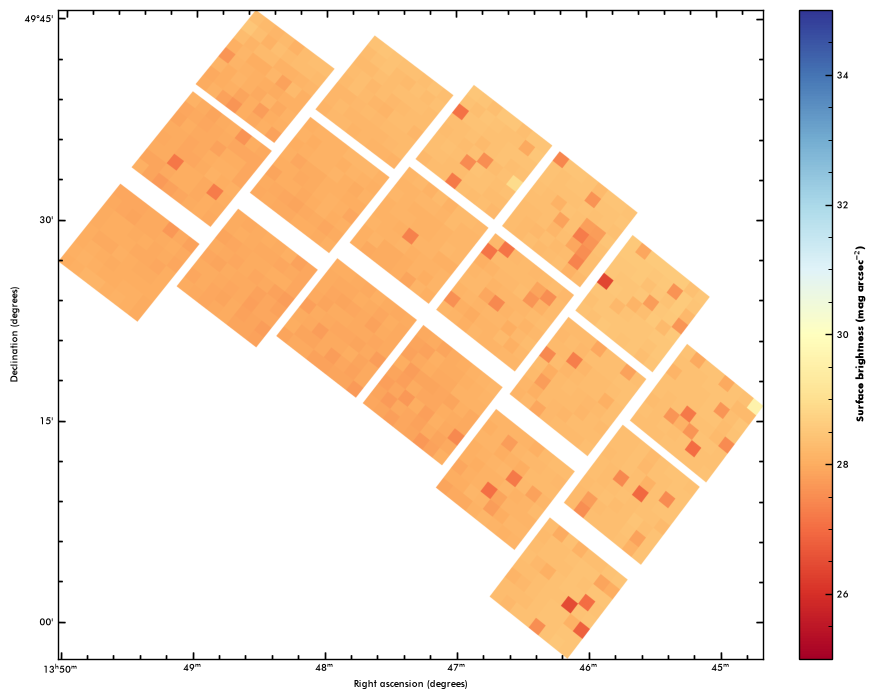

Plot: Stray-light surface brightness flux.
0.0019704008
0.0036837135


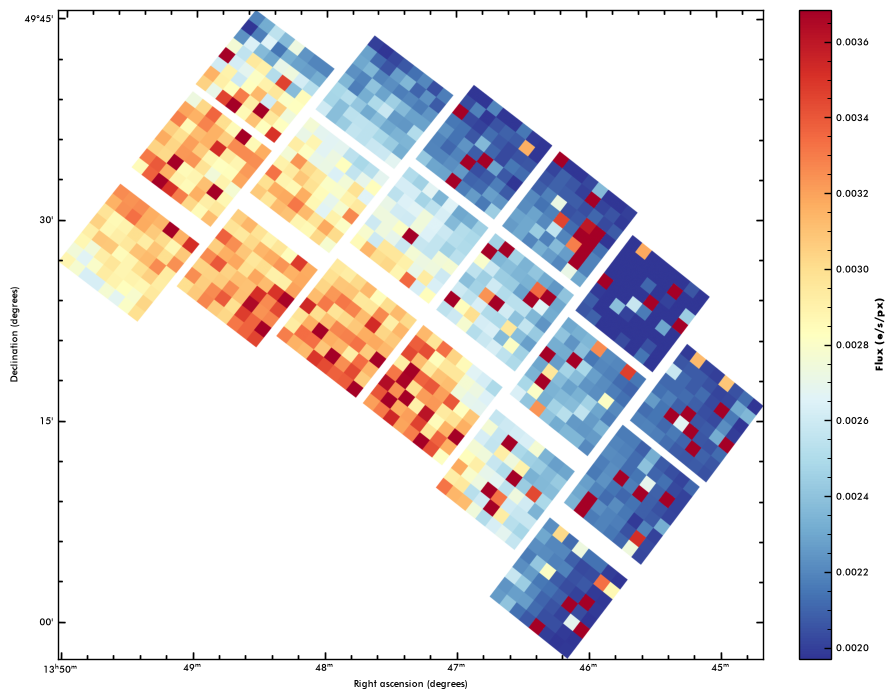

Plot: Main offender map.
142.0
142.0
Unique IDs:
[  2 142]
Unique IDs with counts > 1:
[  2 142]
Simbad cannot find the name of the offender at 165.83276 - 19.03936
Simbad cannot find the name of the offender at 206.8856 - 49.3133
Main stray-light offenders:

95.29% - (206.89, 49.31), m=2.44 - CAT_ID_142
4.71% - (165.83, 19.04), m=-9.66 - CAT_ID_2


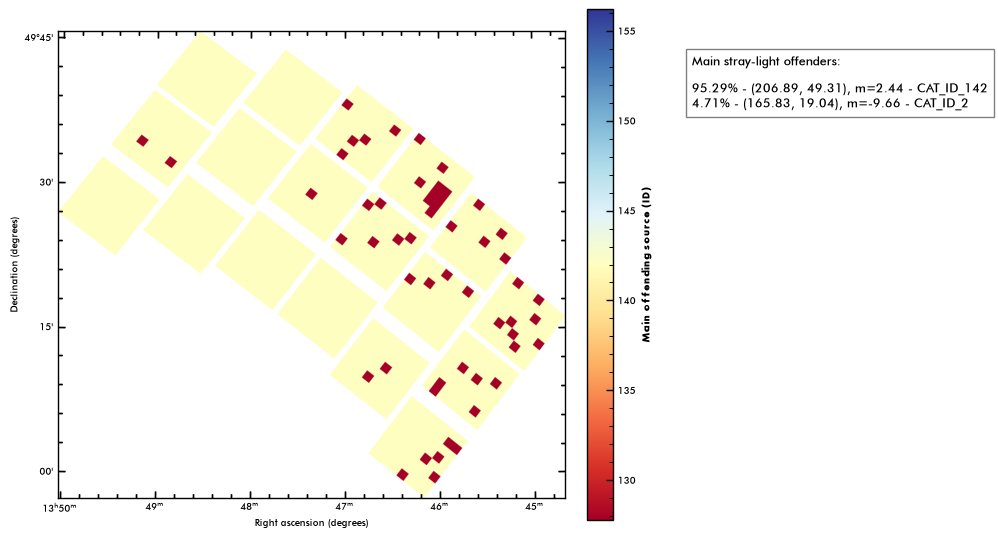

Plot: Source environment map.
SSO body: Sun not found. Skipping
SSO body: Moon not found. Skipping
SSO body: Earth not found. Skipping
SSO body: Mercury not found. Skipping
SSO body: Venus not found. Skipping
SSO body: Mars not found. Skipping
SSO body: Jupiter not found. Skipping
SSO body: Saturn not found. Skipping
SSO body: Uranus not found. Skipping
SSO body: Neptune not found. Skipping
SSO body: Pluto not found. Skipping


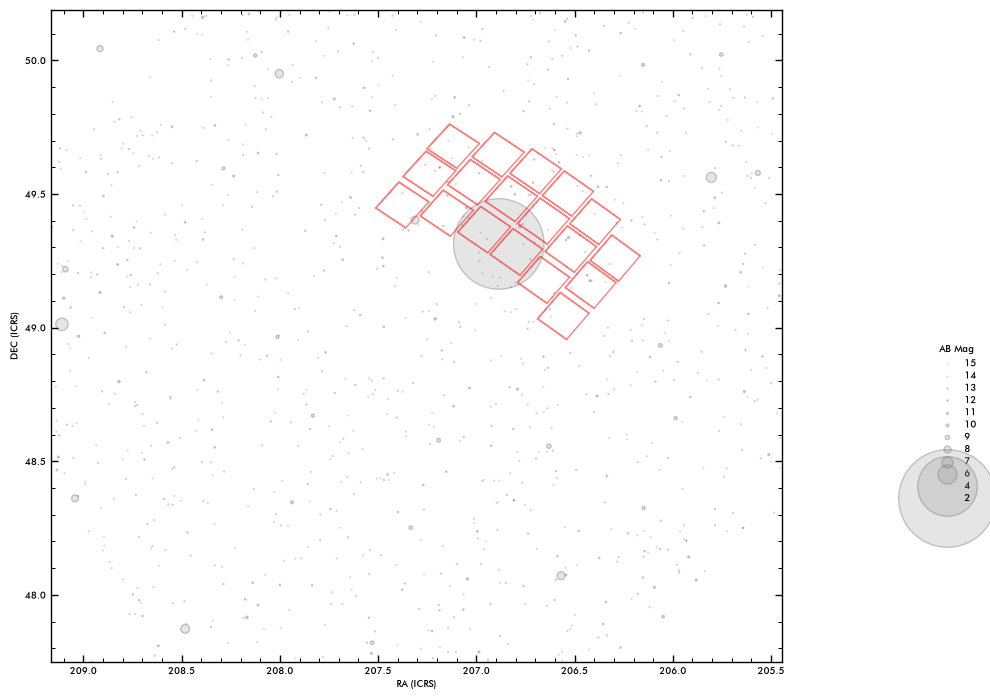

Plot: Location of Main offenders on NDI map.
Unique IDs:
[  2 142]
Unique IDs with counts > 1:
[  2 142]
Simbad cannot find the name of the offender at 165.83276 - 19.03936
Simbad cannot find the name of the offender at 206.8856 - 49.3133
Main stray-light offenders:

95.29% - (206.89, 49.31), m=2.44 - CAT_ID_142
4.71% - (165.83, 19.04), m=-9.66 - CAT_ID_2
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 207.30822381669057 48.96148505136774
CRPIX : 636.5 636.5
NAXIS : 1273  1273
2026-09-22T16:10:17.220483 > Done
Output saved in: r0102203053001002001_0001_wfi18_f087_cal_stray.fits
Report saved in: r0102203053001002001_0001_wfi18_f087_cal_stray.pdf


{'straylevel_db':     SCA  xmid  ymid       ramid     decmid  xmin  ymin  xmax  ymax  \
 0     1   255   255  206.842408  49.376173     0     0   511   511   
 1     1   255   766  206.856971  49.364078     0   511   511  1022   
 2     1   255  1277  206.871527  49.351980     0  1022   511  1533   
 3     1   255  1788  206.886075  49.339882     0  1533   511  2044   
 4     1   255  2299  206.900617  49.327781     0  2044   511  2555   
 ..  ...   ...   ...         ...        ...   ...   ...   ...   ...   
 59   18  3832  1788  206.349053  49.300426  3577  1533  4088  2044   
 60   18  3832  2299  206.362808  49.288573  3577  2044  4088  2555   
 61   18  3832  2810  206.376556  49.276718  3577  2555  4088  3066   
 62   18  3832  3321  206.390297  49.264861  3577  3066  4088  3577   
 63   18  3832  3832  206.404032  49.253003  3577  3577  4088  4088   
 
     straylight_total  mainoffender_total  
 0           0.003018                 142  
 1           0.003138                 142

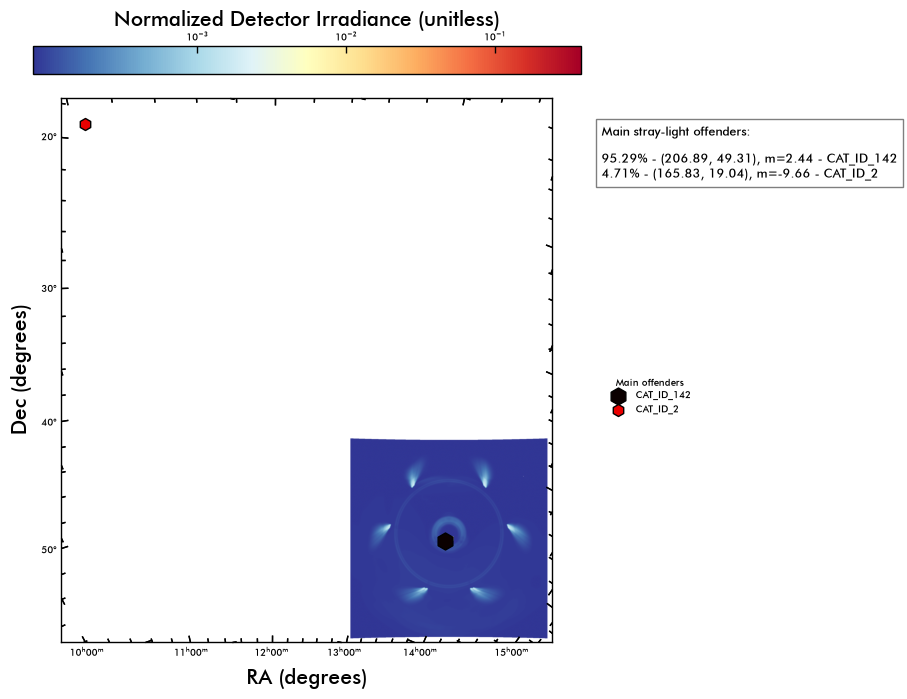

In [35]:
roman_exposure.save_drz(outname=exposures[0] + ".fits", resolution=0.11)
roman_exposure.straylight()


In [36]:
roman_exposure.make_close_stars_ds9_region()

nearby_stars.reg


## About this Notebook

**Author:** Alejandro S. Borlaff - NASA Ames Research Center (Code S) - a.s.borlaff@nasa.gov 

**Updated on** September 20, 2026. 